## Load data

In [3]:
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so

from pymutspec.draw import plot_mutspec12
from pymutspec.annotation import CodonAnnotation
from pymutspec.constants import possible_codons
from pymutspec.io import read_genbank_ref

from scipy.spatial.distance import euclidean, cityblock, pdist, squareform
from scipy.stats import chisquare, ks_2samp, pearsonr, spearmanr, uniform
from scipy.special import kl_div
from sklearn.metrics import mean_squared_error, r2_score
import tqdm
import pingouin as pg

from utils import (
    amino_acid_codes, alphabet, cdn_spectrum_to_matrix, 
    nuc_spectrum_to_matrix, collect_possible_changes,
    get_equilibrium_probabilities, plot_exp_heatmap,
    prepare_aa_subst, plot_aa_eq_freqs, prepare_exp_aa_subst,
    calc_metrics,weighted_average_percentage_error, get_equilibrium_freqs
)

In [4]:
coda = CodonAnnotation(1)

In [5]:
aa_freqs_total_dct = pd.read_json('./data/ref_aa_freqs_mean.json', orient='index')[0].to_dict()
aa_freqs_total_dct

{'Arg': 350,
 'Val': 782,
 'Cys': 296,
 'Gly': 577,
 'Ser': 661,
 'Ala': 659,
 'Leu': 930,
 'Thr': 718,
 'Pro': 394,
 'Asp': 511,
 'Tyr': 448,
 'Phe': 501,
 'Ile': 513,
 'Asn': 532,
 'Lys': 562,
 'Gln': 365,
 'Glu': 442,
 'His': 189,
 'Met': 207,
 'Trp': 111}

In [6]:
## read external clades spectra
# https://raw.githubusercontent.com/jbloomlab/SARS2-mut-spectrum/refs/heads/main/results/synonymous_mut_rates/rates_by_clade.csv

clades_spectra = pd.read_csv('data/bloom_etal/rates_by_clade.csv').query('subset == "all"')
clades_spectra['Mut'] = clades_spectra['mut_type'].str.replace('to', '>')
spectrum_20A = clades_spectra[clades_spectra['clade'] == '20A'].copy()
spectrum_20A['rate'] /= spectrum_20A['rate'].sum()
spectrum_24A = clades_spectra[clades_spectra['clade'] == '24A'].copy()
spectrum_24A['rate'] /= spectrum_24A['rate'].sum()

_clades_order = clades_spectra.drop_duplicates(subset='clade').set_index('clade')

_1 = {x:'Early clades' for x in _clades_order.loc[:'21J'].index.unique()}
_2 = {x:'Late clades\n(Omicron+)' for x in _clades_order.loc['21K':].index.unique()}

_clade2label = {**_1, **_2}
_clade2label

{'20A': 'Early clades',
 '20B': 'Early clades',
 '20C': 'Early clades',
 '20E': 'Early clades',
 '20G': 'Early clades',
 '20I': 'Early clades',
 '20J': 'Early clades',
 '21C': 'Early clades',
 '21I': 'Early clades',
 '21J': 'Early clades',
 '21K': 'Late clades\n(Omicron+)',
 '21L': 'Late clades\n(Omicron+)',
 '22A': 'Late clades\n(Omicron+)',
 '22B': 'Late clades\n(Omicron+)',
 '22C': 'Late clades\n(Omicron+)',
 '22D': 'Late clades\n(Omicron+)',
 '22E': 'Late clades\n(Omicron+)',
 '22F': 'Late clades\n(Omicron+)',
 '23A': 'Late clades\n(Omicron+)',
 '23B': 'Late clades\n(Omicron+)',
 '23C': 'Late clades\n(Omicron+)',
 '23D': 'Late clades\n(Omicron+)',
 '23F': 'Late clades\n(Omicron+)',
 '24A': 'Late clades\n(Omicron+)'}

In [7]:
aamut_fitness = pd.read_csv('./data/bloom_etal/aamut_fitness_by_clade.csv')
aamut_fitness['aa1'] = aamut_fitness['aa_mutation'].str[0]
aamut_fitness['aa2'] = aamut_fitness['aa_mutation'].str[-1]
aamut_fitness['time_period'] = aamut_fitness.clade.map(_clade2label)
aamut_fitness_ns = aamut_fitness.query('aa1 != aa2 & aa1 != "*" & aa2 != "*"')
aamut_fitness_ns

,clade,gene,clade_founder_aa,mutant_aa,aa_site,aa_mutation,expected_count,actual_count,count_terminal,count_non_terminal,mean_log_size,subset_of_ORF1ab,delta_fitness,aa1,aa2,time_period
4,20A,E,A,D,22,A22D,0.67725,0,0,0,0.0,False,-0.85633,A,D,Early clades
5,20A,E,A,D,32,A32D,0.67725,0,0,0,0.0,False,-0.85633,A,D,Early clades
6,20A,E,A,E,36,A36E,0.67725,0,0,0,0.0,False,-0.85633,A,E,Early clades
7,20A,E,A,E,41,A41E,0.67725,0,0,0,0.0,False,-0.85633,A,E,Early clades
8,20A,E,A,G,22,A22G,0.23810,0,0,0,0.0,False,-0.38947,A,G,Early clades
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2893364,24A,nsp1,Y,D,97,Y97D,0.25363,0,0,0,0.0,True,-0.41029,Y,D,Late clades\n(Omicron+)
2893365,24A,nsp1,Y,F,97,Y97F,0.77908,0,0,0,0.0,True,-0.93929,Y,F,Late clades\n(Omicron+)
2893366,24A,nsp1,Y,H,97,Y97H,2.17910,0,0,0,0.0,True,-1.67860,Y,H,Late clades\n(Omicron+)
2893367,24A,nsp1,Y,N,97,Y97N,0.48805,0,0,0,0.0,True,-0.68113,Y,N,Late clades\n(Omicron+)


## Fitness of distinct AA

### Prepare site samples of different fitness landscapes

In [21]:
aa_fitness = pd.read_csv('./data/bloom_etal/aa_fitness.csv')
aa_fitness

,gene,aa_site,aa,fitness,expected_count,aa_differs_among_clade_founders,subset_of_ORF1ab
0,E,1,I,-7.1032,607.410,False,False
1,E,1,K,-3.5840,17.508,False,False
2,E,1,L,-4.3124,36.811,False,False
3,E,1,M,0.0000,844.230,False,False
4,E,1,R,-3.1560,11.238,False,False
...,...,...,...,...,...,...,...
122158,nsp9,113,K,-3.4869,48.529,False,True
122159,nsp9,113,L,-2.8511,25.461,False,True
122160,nsp9,113,P,-2.0669,11.350,False,True
122161,nsp9,113,Q,0.0000,925.030,False,True


In [22]:
aa_fitness_ref = aa_fitness.query('fitness == 0').set_index(['gene', 'aa_site'])
aa_fitness_ref

aa  fitness  expected_count  aa_differs_among_clade_founders  \
gene aa_site                                                                
E    1        M      0.0          844.23                            False   
     2        Y      0.0          302.17                            False   
     3        S      0.0          873.08                            False   
     4        F      0.0          287.04                            False   
     5        V      0.0          718.24                            False   
...          ..      ...             ...                              ...   
nsp9 109      T      0.0          888.22                            False   
     110      V      0.0          718.25                            False   
     111      R      0.0         1369.60                            False   
     112      L      0.0          176.26                            False   
     113      Q      0.0          925.03                            False   

              subset_of_ORF1ab  
gene aa_site                    
E    1                   False  
     2                   False  
     3                   False  
     4                   False  
     5                   False  
...                        ...  
nsp9 109                  True  
     110                  True  
     111                  True  
     112                  True  
     113                  True  

[16764 rows x 5 columns]

In [8]:
# ref fitness is 0
aa_fitness_ref.fitness.describe()

count    16764.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: fitness, dtype: float64

In [23]:
site_fitnesses = aa_fitness.pivot(index=['gene', 'aa_site'], columns='aa', values='fitness').fillna(0)
site_fitnesses

aa                  *        A       C      D       E       F       G  \
gene aa_site                                                            
E    1        0.00000  0.00000  0.0000  0.000  0.0000  0.0000  0.0000   
     2       -3.78190  0.00000 -5.1893 -3.156  0.0000 -2.8511  0.0000   
     3       -4.88050 -0.95878  0.0000  0.000  0.0000  0.0000  0.0000   
     4        0.00000  0.00000 -3.1560  0.000  0.0000  0.0000  0.0000   
     5        0.00000 -2.27390  0.0000 -3.584  0.0000 -2.2231 -2.0574   
...               ...      ...     ...    ...     ...     ...     ...   
nsp9 109      0.00000 -5.18930  0.0000  0.000  0.0000  0.0000  0.0000   
     110      0.00000 -5.10710  0.0000  0.000 -2.4854  0.0000 -2.0574   
     111      0.00000  0.00000 -7.2405  0.000  0.0000  0.0000 -3.5451   
     112     -0.79691  0.00000  0.0000  0.000  0.0000 -1.0741  0.0000   
     113     -5.63110  0.00000  0.0000  0.000 -2.4465  0.0000  0.0000   

aa                  H        I       K  ...    M      N       P       Q  \
gene aa_site                            ...                               
E    1        0.00000 -7.10320 -3.5840  ...  0.0  0.000  0.0000  0.0000   
     2       -2.27390  0.00000  0.0000  ...  0.0 -3.584  0.0000  0.0000   
     3        0.00000  0.00000  0.0000  ...  0.0  0.000 -0.7633  0.0000   
     4        0.00000 -2.48540  0.0000  ...  0.0  0.000  0.0000  0.0000   
     5        0.00000  0.72401  0.0000  ...  0.0  0.000  0.0000  0.0000   
...               ...      ...     ...  ...  ...    ...     ...     ...   
nsp9 109      0.00000  1.11350 -2.0206  ...  0.0  0.000 -3.1655  0.0000   
     110      0.00000 -1.46820  0.0000  ...  0.0  0.000  0.0000  0.0000   
     111     -4.85820  0.00000  0.0000  ...  0.0  0.000 -1.8907  0.0000   
     112      0.00000 -0.80668  0.0000  ...  0.0  0.000 -5.0843 -3.5662   
     113     -0.81593  0.00000 -3.4869  ...  0.0  0.000 -2.0669  0.0000   

aa                 R       S       T       V    W       Y  
gene aa_site                                               
E    1       -3.1560  0.0000 -5.1071 -4.0907  0.0  0.0000  
     2        0.0000 -3.1655  0.0000  0.0000  0.0  0.0000  
     3        0.0000  0.0000 -1.1861  0.0000  0.0  0.0000  
     4        0.0000 -3.1612  0.0000 -3.1560  0.0 -1.9745  
     5        0.0000  0.0000  0.0000  0.0000  0.0  0.0000  
...              ...     ...     ...     ...  ...     ...  
nsp9 109     -3.5451 -3.9498  0.0000  0.0000  0.0  0.0000  
     110      0.0000  0.0000  0.0000  0.0000  0.0  0.0000  
     111      0.0000 -4.5855  0.0000  0.0000  0.0  0.0000  
     112     -3.1308 -1.5527  0.0000 -2.4446  0.0  0.0000  
     113     -5.1893  0.0000  0.0000  0.0000  0.0  0.0000  

[16764 rows x 21 columns]

In [25]:
X_descr = aa_fitness.query('aa != "*" & fitness != 0')\
    .groupby(['gene', 'aa_site'])['fitness'].aggregate(['min', 'max', 'mean', 'median', 'std', 'count']).join(
        aa_fitness.query('aa != "*"').groupby(['gene', 'aa_site'])\
            ['fitness'].max().rename('max=0') == 0)
X_descr = X_descr.join(aa_fitness_ref[['aa', 'subset_of_ORF1ab']]).rename(columns={'aa': 'ref_aa'})
X_descr

min      max      mean   median       std  count  max=0  \
gene aa_site                                                               
E    1       -7.1032 -3.15600 -4.558900 -4.20155  1.412269      6   True   
     2       -5.1893 -2.27390 -3.369967 -3.16075  0.991358      6   True   
     3       -2.4956 -0.76330 -1.350945 -1.07244  0.782417      4   True   
     4       -3.1612 -0.36699 -2.383348 -2.82070  1.099300      6   True   
     5       -3.5840  0.72401 -1.498047 -2.14025  1.698920      6  False   
...              ...      ...       ...      ...       ...    ...    ...   
nsp9 109     -5.1893  1.11350 -2.792800 -3.35530  2.174497      6  False   
     110     -5.1071 -1.46820 -2.825300 -2.48540  1.395265      5   True   
     111     -7.2405 -1.89070 -4.397983 -4.42670  1.752579      6   True   
     112     -5.0843 -0.80668 -2.522769 -2.44460  1.528106      7   True   
     113     -5.1893 -0.81593 -2.809438 -2.64880  1.468441      6   True   

             ref_aa  subset_of_ORF1ab  
gene aa_site                           
E    1            M             False  
     2            Y             False  
     3            S             False  
     4            F             False  
     5            V             False  
...             ...               ...  
nsp9 109          T              True  
     110          V              True  
     111          R              True  
     112          L              True  
     113          Q              True  

[16764 rows x 9 columns]

In [26]:
X_descr['count'].value_counts()

count
6     10663
7      2731
5      2171
4       964
9       126
10       44
8        32
11       14
3         8
13        5
12        5
14        1
Name: count, dtype: int64

In [27]:
# Sharp peaks
# X_descr.query('mean < -3')
# sites_plateau = X_descr.query('-1 < mean < 1 & std < 1.5')

## initial classification with some assumtions
# X_descr['landscape_char'] = 'none'
# X_descr.loc[(X_descr['mean'] < -3), 'landscape_char'] = 'rock'
# X_descr.loc[(X_descr['mean'].between(-3, -1))&(X_descr['max=0']), 'landscape_char'] = 'hill'
# X_descr.loc[(X_descr['mean'].between(-3, -1))&(~X_descr['max=0']), 'landscape_char'] = 'climb'
# X_descr.loc[(X_descr['mean'].between(-1, 2 ))&(X_descr['std'] < 1), 'landscape_char'] = 'plateau'
# X_descr.loc[(X_descr['mean'].between(-1, 2 ))&(X_descr['std'] > 1), 'landscape_char'] = 'canyon'


X_descr.loc[(X_descr['max=0']), 'landscape_char'] = 'ref_is_highest'
X_descr.loc[(~X_descr['max=0']), 'landscape_char'] = 'ref_is_not_highest'


In [28]:
X_descr.landscape_char.value_counts()

landscape_char
ref_is_highest        9946
ref_is_not_highest    6818
Name: count, dtype: int64

Text(0.5, 0, 'mean (mount height)')

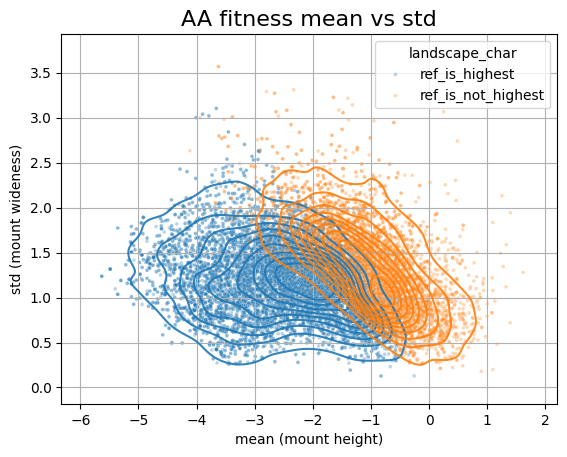

In [56]:
ax=sns.kdeplot(X_descr.sample(frac=0.5), x='mean', y='std', hue='landscape_char', alpha=0.9)
sns.scatterplot(X_descr, x='mean', y='std', hue='landscape_char', alpha=0.3, s=7, ax=ax)
plt.title('AA fitness mean vs std', fontsize=16)
# plt.plot([-3, 0], [0, 3])
# plt.vlines([-1, 2], 0, 1.5, color='purple', linestyle='--', label='plateau')
# plt.hlines([0, 1.5], -1, 2, color='purple', linestyle='--', label='plateau')
# plt.vlines([-3], 0, 3, color='red', linestyle='--', label='peak')
plt.grid()
plt.ylabel('std (mount wideness)')
plt.xlabel('mean (mount height)')

In [29]:
X_descr.to_csv('./data/sites_landscape_labels.csv')

### Assess model on different landscapes

In [33]:
X_descr = pd.read_csv('./data/sites_landscape_labels.csv', index_col=[0,1])
X_descr.head()

min      max      mean   median       std  count  max=0  \
gene aa_site                                                               
E    1       -7.1032 -3.15600 -4.558900 -4.20155  1.412269      6   True   
     2       -5.1893 -2.27390 -3.369967 -3.16075  0.991358      6   True   
     3       -2.4956 -0.76330 -1.350945 -1.07244  0.782417      4   True   
     4       -3.1612 -0.36699 -2.383348 -2.82070  1.099300      6   True   
     5       -3.5840  0.72401 -1.498047 -2.14025  1.698920      6  False   

             ref_aa  subset_of_ORF1ab      landscape_char  
gene aa_site                                               
E    1            M             False      ref_is_highest  
     2            Y             False      ref_is_highest  
     3            S             False      ref_is_highest  
     4            F             False      ref_is_highest  
     5            V             False  ref_is_not_highest

In [37]:
aamut_fitness_ns_lbl = aamut_fitness_ns.merge(X_descr[['landscape_char']].reset_index())
aamut_fitness_ns_lbl.head()

,clade,gene,clade_founder_aa,mutant_aa,aa_site,aa_mutation,expected_count,actual_count,count_terminal,count_non_terminal,mean_log_size,subset_of_ORF1ab,delta_fitness,aa1,aa2,landscape_char
0,20A,E,A,D,22,A22D,0.67725,0,0,0,0.0,False,-0.85633,A,D,ref_is_highest
1,20A,E,A,D,32,A32D,0.67725,0,0,0,0.0,False,-0.85633,A,D,ref_is_highest
2,20A,E,A,E,36,A36E,0.67725,0,0,0,0.0,False,-0.85633,A,E,ref_is_highest
3,20A,E,A,E,41,A41E,0.67725,0,0,0,0.0,False,-0.85633,A,E,ref_is_highest
4,20A,E,A,G,22,A22G,0.23810,0,0,0,0.0,False,-0.38947,A,G,ref_is_highest


In [39]:
aamut_fitness_ns_lbl.groupby(['landscape_char', 'subset_of_ORF1ab']).actual_count.sum().unstack()

subset_of_ORF1ab,False,True
landscape_char,,
ref_is_highest,707126,550786
ref_is_not_highest,2439655,1361497


In [68]:
aamut_fitness_ns_lbl.groupby('subset_of_ORF1ab').gene.unique()

subset_of_ORF1ab
False    [E, M, N, ORF10, ORF1ab, ORF3a, ORF6, ORF7a, O...
True     [nsp3, nsp1, nsp2, nsp4, nsp5 (Mpro), nsp6, ns...
Name: gene, dtype: object

In [40]:
clades_mut_cnt = aamut_fitness_ns.groupby('clade')['actual_count'].sum()#.sort_values()
clades_mut_cnt[clades_mut_cnt>100000]

clade
20A     103442
20I     335836
21I     132706
21J    1603754
21K     627867
21L     502165
22B     543905
22E     150185
23A     149559
24A     105676
Name: actual_count, dtype: int64

In [ ]:
data_fitness_sites = []
d_to_eq_data = []
for clade in clades_mut_cnt.index:
    print(clade, end=' ')
    spectrum_cur = clades_spectra[clades_spectra['clade'] == clade].copy()
    spectrum_cur['rate'] /= spectrum_cur['rate'].sum()

    exp_aa_subst_cur = prepare_exp_aa_subst(spectrum_cur)[0]
    
    n_to_sample = aamut_fitness_ns_lbl.query(f'clade == "{clade}"').groupby('landscape_char')\
        ['actual_count'].sum().sort_values().iloc[0]

    for (lchar, genome_part), cur_aamut in aamut_fitness_ns_lbl\
        .groupby(['landscape_char', 'subset_of_ORF1ab']):

        cur_aa_freqs_dct = X_descr\
            .query(f'landscape_char == "{lchar}" & subset_of_ORF1ab == {genome_part}')\
                .ref_aa.value_counts().rename(index=amino_acid_codes).to_dict()

        cur_aamut_flt = cur_aamut\
            .query(f'clade == "{clade}" & actual_count > 0')\
                .rename(columns={'actual_count': 'count'})


        aas = prepare_aa_subst(cur_aamut_flt, exp_aa_subst_cur, cur_aa_freqs_dct)
        cur_met = calc_metrics(aas)
        data_fitness_sites.append({
            'clade': clade,
            'landscape_char': lchar,
            'subset_of_ORF1ab': genome_part, 
            'r2': cur_met['r2'], 
            'spearman_corr': cur_met['spearman_corr'], 
            'mut_count': cur_met['mut_count'], 
            'mut_type_count': aas.nobs.ne(0).sum(), 
        })

        # calculate distance to equilibrium frequencies
        _, cur_aa_eq_freq = get_equilibrium_freqs(spectrum_cur, 'rate')

        cur_aa_eq_freq['obs_cnt'] = cur_aa_eq_freq['aa'].map(cur_aa_freqs_dct).fillna(0)
        cur_aa_eq_freq['obs_freq'] = cur_aa_eq_freq['obs_cnt'] / cur_aa_eq_freq['obs_cnt'].sum()

        dm = cityblock(cur_aa_eq_freq['eq_freq'], cur_aa_eq_freq['obs_freq'])
        de = euclidean(cur_aa_eq_freq['eq_freq'], cur_aa_eq_freq['obs_freq'])
        top5_gainer_frac = cur_aa_eq_freq.sort_values('eq_freq').tail()[['eq_freq', 'obs_freq']].sum().to_dict()

        d_to_eq_data.append({
            'clade': clade,
            'landscape_char': lchar,
            'subset_of_ORF1ab': genome_part, 
            'cityblock': dm, 
            'euclidean': de, 
            'top5_gainer_frac_eq': top5_gainer_frac['eq_freq'],
            'top5_gainer_frac_obs': top5_gainer_frac['obs_freq'],
        })

d_to_eq_df = pd.DataFrame(d_to_eq_data)
d_to_eq_df['time_period'] = d_to_eq_df['clade'].map(_clade2label)

data_fitness_sites_df = pd.DataFrame(data_fitness_sites)
data_fitness_sites_df['time_period'] = data_fitness_sites_df['clade'].map(_clade2label)

data_fitness_sites_df.head()

20A 20B 20C 20E 20G 20I 20J 21C 21I 21J 21K 21L 22A 22B 22C 22D 22E 22F 23A 23B 23C 23D 23F 24A 

,clade,landscape_char,subset_of_ORF1ab,r2,spearman_corr,mut_count,mut_type_count,time_period
0,20A,ref_is_highest,False,0.464623,0.813831,14624.0,146,Early clades
1,20A,ref_is_highest,True,0.447730,0.789728,11589.0,146,Early clades
2,20A,ref_is_not_highest,False,0.651325,0.819354,49941.0,149,Early clades
3,20A,ref_is_not_highest,True,0.590019,0.750511,27288.0,143,Early clades
4,20B,ref_is_highest,False,0.444653,0.822310,12089.0,147,Early clades


In [23]:
data_fitness_sites_df.clade.nunique()

24

### Plot model quality for landscapes

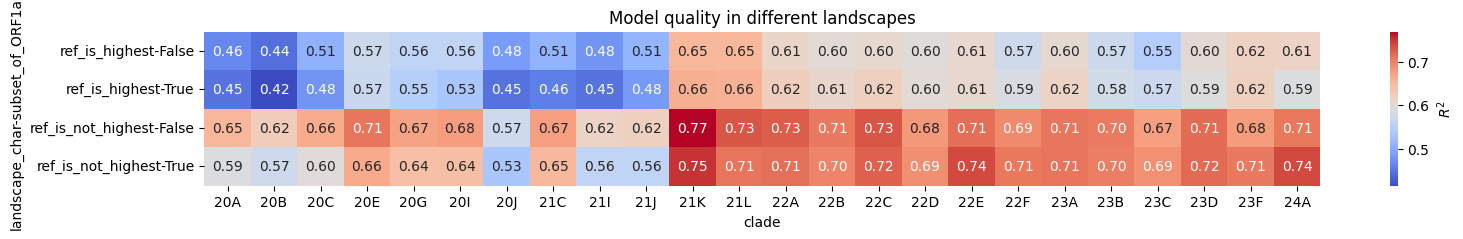

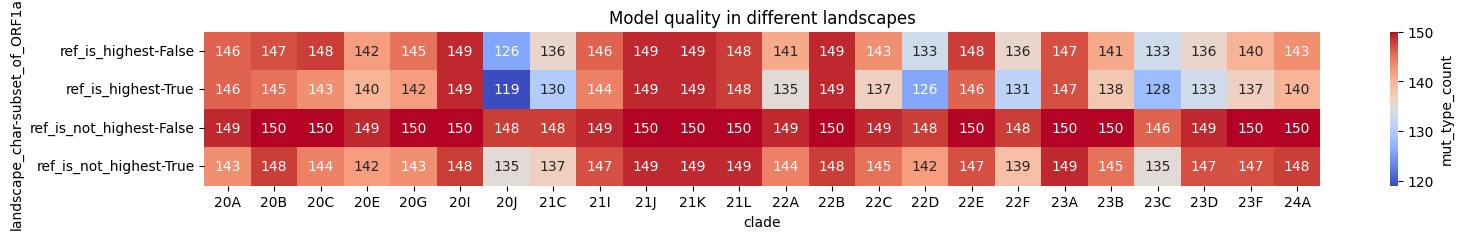

In [73]:
plt.figure(figsize=(18, 2))
_ = data_fitness_sites_df.pivot(columns='clade', index=['landscape_char', 'subset_of_ORF1ab'], values='r2')
sns.heatmap(_, annot=True, fmt='.2f', cmap='coolwarm', cbar_kws={'label': '$R^2$'})
plt.title('Model quality in different landscapes')
plt.yticks(rotation=0)
plt.show()

plt.figure(figsize=(18, 2))
_ = data_fitness_sites_df.pivot(columns='clade', index=['landscape_char', 'subset_of_ORF1ab'], values='mut_type_count')
sns.heatmap(_, annot=True, fmt='.0f', cmap='coolwarm', cbar_kws={'label': 'mut_type_count'})
plt.title('Model quality in different landscapes')
plt.yticks(rotation=0)
plt.show()

/tmp/ipykernel_62778/1340716598.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Ранние клады', 'Поздние клады\n(Омикрон+)'], fontsize=12)


[Text(0, 0, 'Ранние клады'), Text(1, 0, 'Поздние клады\n(Омикрон+)')]

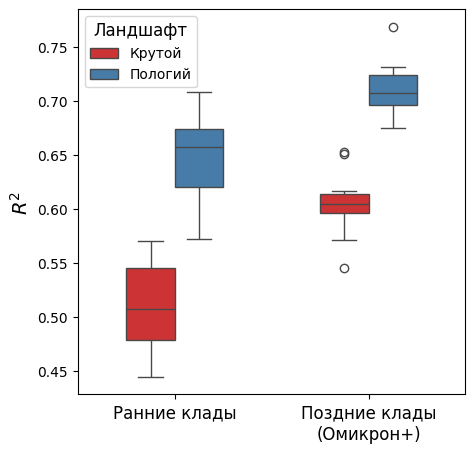

In [ ]:
# only for subset_of_ORF1ab == False, i.e. all genes without dublicates

plt.figure(figsize=(5, 5))
_ = data_fitness_sites_df.query('subset_of_ORF1ab == False').copy()
_['landscape_char'] = _.landscape_char.map({'ref_is_highest': 'Крутой', 
                                            'ref_is_not_highest': 'Пологий'})
ax = sns.boxplot(
    data=_, width=0.5,
    order=sorted(data_fitness_sites_df['time_period'].unique()),
    hue='landscape_char', y='r2', x='time_period', palette='Set1',
)
plt.ylabel('$R^2$', fontsize=14)
plt.xlabel('')
plt.legend(title='Ландшафт', fontsize=10, title_fontsize=12)
ax.set_xticklabels(['Ранние клады', 'Поздние клады\n(Омикрон+)'], fontsize=12)

In [100]:
_ = data_fitness_sites_df.query('time_period == "Early clades"')
pg.pairwise_tests(_, dv='r2', within='landscape_char', subject='clade',)

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
0,landscape_char,ref_is_highest,ref_is_not_highest,True,True,-12.652787,9.0,two-sided,4.897619e-07,2.876e+04,-2.797154


In [101]:
_ = data_fitness_sites_df.query('time_period != "Early clades"')
pg.pairwise_tests(_, dv='r2', within='landscape_char', subject='clade')

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
0,landscape_char,ref_is_highest,ref_is_not_highest,True,True,-20.735191,13.0,two-sided,2.407462e-11,2.801e+08,-4.292216


### plot distance to equilibrium in different landscapes

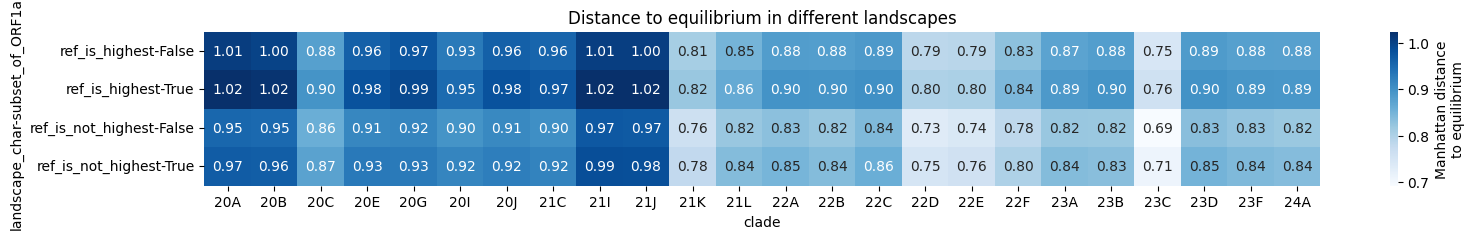

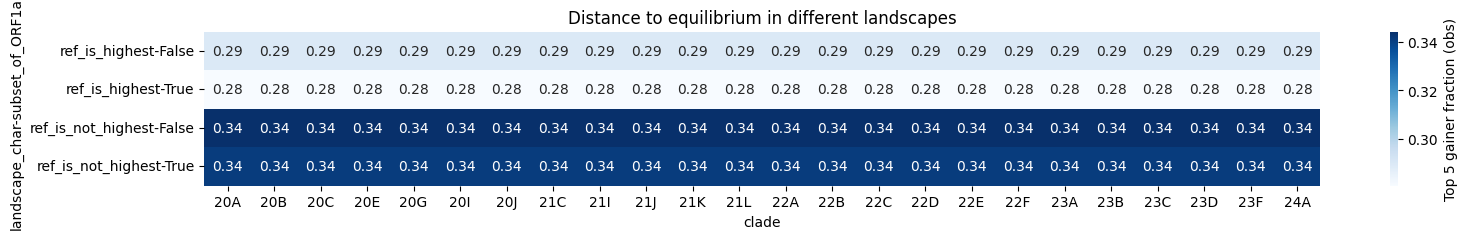

In [ ]:
plt.figure(figsize=(18, 2))
_ = d_to_eq_df.pivot(index=['landscape_char', 'subset_of_ORF1ab'], columns='clade', values='cityblock')
sns.heatmap(_, annot=True, fmt='.2f', cmap='Blues', cbar_kws={'label': 'Manhattan distance\nto equilibrium'})
plt.title('Distance to equilibrium in different landscapes')
plt.yticks(rotation=0)
plt.show()

/tmp/ipykernel_62778/172347156.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Ранние клады', 'Поздние клады\n(Омикрон+)'], fontsize=12)


[Text(0, 0, 'Ранние клады'), Text(1, 0, 'Поздние клады\n(Омикрон+)')]

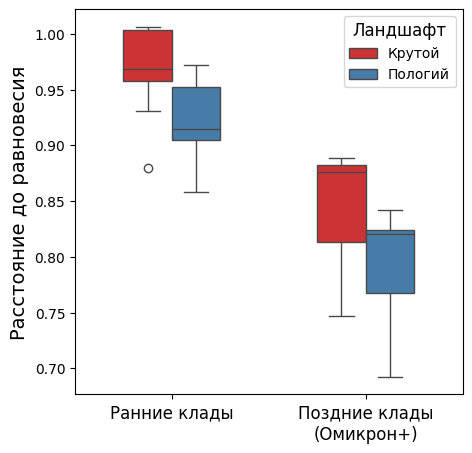

In [77]:
plt.figure(figsize=(5, 5))
_ = d_to_eq_df.query('subset_of_ORF1ab == False').copy()
_['landscape_char'] = _.landscape_char.map({'ref_is_highest': 'Крутой', 
                                            'ref_is_not_highest': 'Пологий'})
ax = sns.boxplot(
    data=_, width=0.5,
    order=sorted(d_to_eq_df['time_period'].unique()),
    hue='landscape_char', y='cityblock', x='time_period', palette='Set1',
)
plt.ylabel('Расстояние до равновесия', fontsize=14)
plt.xlabel('')
plt.legend(title='Ландшафт', fontsize=10, title_fontsize=12)
ax.set_xticklabels(['Ранние клады', 'Поздние клады\n(Омикрон+)'], fontsize=12)

In [ ]:
# top5 gainer fraction 29% and 34%
_ = d_to_eq_df.query('clade == "20A"')
_

,clade,landscape_char,subset_of_ORF1ab,cityblock,euclidean,top5_gainer_frac_eq,top5_gainer_frac_obs,time_period
0,20A,ref_is_highest,False,1.006171,0.327179,0.792281,0.289436,Early clades
1,20A,ref_is_highest,True,1.023830,0.332449,0.792281,0.280365,Early clades
2,20A,ref_is_not_highest,False,0.953074,0.340430,0.792281,0.344431,Early clades
3,20A,ref_is_not_highest,True,0.967248,0.348053,0.792281,0.341279,Early clades


In [99]:
_ = d_to_eq_df.query('time_period == "Early clades"')
pg.pairwise_tests(_, dv='cityblock', within='landscape_char', subject='clade',)

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
0,landscape_char,ref_is_highest,ref_is_not_highest,True,True,11.4085,9.0,two-sided,0.000001,1.328e+04,1.125327


In [98]:
_ = d_to_eq_df.query('time_period != "Early clades"')
pg.pairwise_tests(_, dv='cityblock', within='landscape_char', subject='clade')

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
0,landscape_char,ref_is_highest,ref_is_not_highest,True,True,21.924807,13.0,two-sided,1.187892e-11,5.36e+08,1.031209


In [93]:
pg.homoscedasticity(d_to_eq_df.query('subset_of_ORF1ab == False'), dv='cityblock', group='landscape_char')

,W,pval,equal_var
levene,0.043226,0.836217,True


In [ ]:
pg.normality(d_to_eq_df, dv='cityblock', group='landscape_char')

,W,pval,normal
landscape_char,,,
ref_is_highest,0.937672,0.144731,True
ref_is_not_highest,0.956887,0.379126,True


In [ ]:
pg.normality(d_to_eq_df, dv='cityblock', group='time_period')

,W,pval,normal
time_period,,,
Late clades\n(Omicron+),0.926596,0.050623,True
Early clades,0.949254,0.355909,True


In [ ]:
pg.anova(d_to_eq_df, dv='cityblock', between='time_period')

,Source,ddof1,ddof2,F,p-unc,np2
0,time_period,1,46,74.685793,3.406726e-11,0.618845


In [ ]:
pg.rm_anova(d_to_eq_df, dv='cityblock', within='landscape_char', subject='clade')

,Source,ddof1,ddof2,F,p-unc,ng2,eps
0,landscape_char,1,23,532.206642,2.105901e-17,0.097488,1.0


In [ ]:
pg.pairwise_tests(d_to_eq_df, dv='cityblock', within='landscape_char', subject='clade', between='time_period')

,Contrast,landscape_char,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
0,landscape_char,-,ref_is_highest,ref_is_not_highest,True,True,23.069604,23.000000,two-sided,2.105901e-17,2.084e+14,0.632935
1,time_period,-,Early clades,Late clades\n(Omicron+),False,True,7.231257,21.538720,two-sided,3.436688e-07,3.259e+04,2.790286
2,landscape_char * time_period,ref_is_highest,Early clades,Late clades\n(Omicron+),False,True,6.797886,21.106203,two-sided,9.823604e-07,1.38e+04,2.649046
3,landscape_char * time_period,ref_is_not_highest,Early clades,Late clades\n(Omicron+),False,True,7.577115,21.790801,two-sided,1.529120e-07,6.393e+04,2.900797


### AA delta_fitness AND AA fitness 

In [247]:
fast_sites = pd.read_csv('./data/ref_sites_rates_cat4.csv', index_col=0).query('rate_cat == 4').index.values
fast_sites

array([  274,   275,   278, ..., 29666, 29668, 29670], shape=(4951,))

In [248]:
X_descr

min      max      mean   median       std  count  max=0  \
gene aa_site                                                               
E    1       -7.1032 -3.15600 -4.558900 -4.20155  1.412269      6   True   
     2       -5.1893 -2.27390 -3.369967 -3.16075  0.991358      6   True   
     3       -2.4956 -0.76330 -1.350945 -1.07244  0.782417      4   True   
     4       -3.1612 -0.36699 -2.383348 -2.82070  1.099300      6   True   
     5       -3.5840  0.72401 -1.498047 -2.14025  1.698920      6  False   
...              ...      ...       ...      ...       ...    ...    ...   
nsp9 109     -5.1893  1.11350 -2.792800 -3.35530  2.174497      6  False   
     110     -5.1071 -1.46820 -2.825300 -2.48540  1.395265      5   True   
     111     -7.2405 -1.89070 -4.397983 -4.42670  1.752579      6   True   
     112     -5.0843 -0.80668 -2.522769 -2.44460  1.528106      7   True   
     113     -5.1893 -0.81593 -2.809438 -2.64880  1.468441      6   True   

                  landscape_char  
gene aa_site                      
E    1            ref_is_highest  
     2            ref_is_highest  
     3            ref_is_highest  
     4            ref_is_highest  
     5        ref_is_not_highest  
...                          ...  
nsp9 109      ref_is_not_highest  
     110          ref_is_highest  
     111          ref_is_highest  
     112          ref_is_highest  
     113          ref_is_highest  

[16764 rows x 8 columns]

In [ ]:
data_fitness_sites = []
for clade in clades_mut_cnt[clades_mut_cnt>100000].index:
    print(clade)
    spectrum_cur = clades_spectra[clades_spectra['clade'] == clade].copy()
    spectrum_cur['rate'] /= spectrum_cur['rate'].sum()

    spectrum_dct = spectrum_cur.set_index('Mut').rate.to_dict()
    df_changes = collect_possible_changes(1, spectrum_dct)
    exp_aa_subst_cur = df_changes[(df_changes.aa1 != '*')&(df_changes.aa2 != '*')]\
        .groupby(['aa1', 'aa2'])['rate'].sum().reset_index()

    for lchar in aamut_fitness_ns_lbl.landscape_char.unique():
        print(lchar, end=' ')

        cur_aa_freqs_dct = X_descr.query(f'landscape_char == "{lchar}"')[['landscape_char']]\
            .join(aa_fitness_ref[['aa']]).aa.value_counts().rename(index=amino_acid_codes).to_dict()

        cur_aamut = aamut_fitness_ns_lbl\
            .query(f'clade == "{clade}" & actual_count > 0 & landscape_char == "{lchar}"')\
                .rename(columns={'actual_count': 'count'})
        
        cur_aamut_low_df  = cur_aamut.query('delta_fitness < 0')
        cur_aamut_high_df = cur_aamut.query('delta_fitness >= 0')

        for cur_sample, label in zip([cur_aamut, cur_aamut_low_df, cur_aamut_high_df], 
                                     ['any', 'Δfitness<0', 'Δfitness>0']):

            aas = prepare_aa_subst(cur_sample, exp_aa_subst_cur, cur_aa_freqs_dct)
            cur_met = calc_metrics(aas)
            data_fitness_sites.append({
                'clade': clade,
                'landscape_char': lchar,
                'df_sample': label, 
                'r2': cur_met['r2'], 
                'spearman_corr': cur_met['spearman_corr'], 
                'mut_count': cur_met['mut_count'], 
                'mut_type_count': aas.nobs.ne(0).sum(), 
            })
    print()

data_fitness_sites_df = pd.DataFrame(data_fitness_sites)
data_fitness_sites_df.to_csv('./data/metrics_landscapes_and_df.csv', index=False)

20A
ref_is_highest ref_is_not_highest 
24A
ref_is_highest ref_is_not_highest 
21I
ref_is_highest ref_is_not_highest 
23A
ref_is_highest ref_is_not_highest 
22E
ref_is_highest ref_is_not_highest 
20I
ref_is_highest ref_is_not_highest 
21L
ref_is_highest ref_is_not_highest 
22B
ref_is_highest ref_is_not_highest 
21K
ref_is_highest ref_is_not_highest 
21J
ref_is_highest ref_is_not_highest 


In [112]:
data_fitness_sites_df.head()

,clade,landscape_char,df_sample,r2,spearman_corr,mut_count,mut_type_count
0,20A,ref_is_highest,any,0.457175,0.804500,26213.0,146
1,20A,ref_is_highest,Δfitness<0,0.581366,0.877995,17669.0,71
2,20A,ref_is_highest,Δfitness>0,-0.226992,0.392497,8544.0,136
3,20A,ref_is_not_highest,any,0.639564,0.819285,77229.0,149
4,20A,ref_is_not_highest,Δfitness<0,0.624500,0.879572,15649.0,71


In [151]:
top_clades = data_fitness_sites_df.query('df_sample == "Δfitness<0" & mut_type_count > 120').clade.unique()

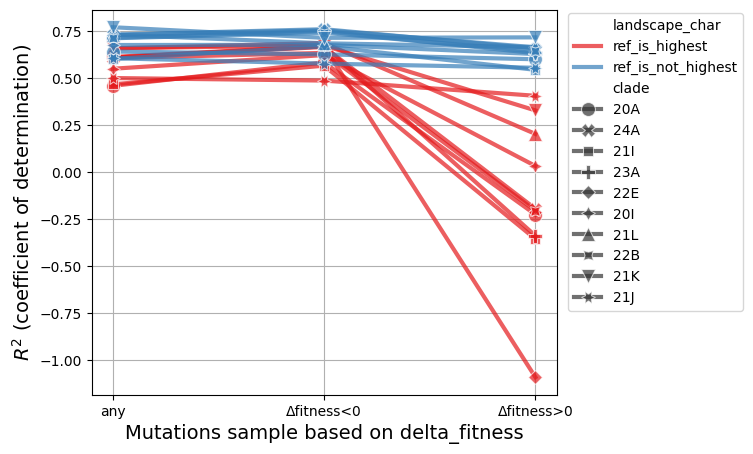

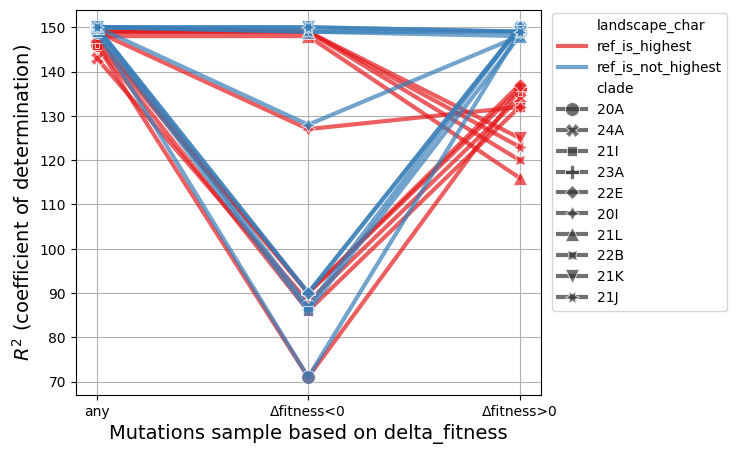

In [ ]:
plt.figure(figsize=(6, 5))
ax = sns.lineplot(
    data_fitness_sites_df, hue='landscape_char', y='r2', style='clade', x='df_sample', 
    markers=True, dashes=False, palette='Set1', alpha=0.7,
    linewidth=3, markersize=10, 
    # style_order=top_clades,
)

ax.grid()
ax.set_axisbelow(True)
ax.set_title('')
# ax.set_xticks(range(1, 5))
ax.set_ylabel('$R^2$ (coefficient of determination)', fontsize=14)
ax.set_xlabel('Mutations sample based on delta_fitness', fontsize=14)

plt.legend(bbox_to_anchor=(1.01, 1.01), loc='upper left')
# plt.grid(axis='y', alpha=0.7)
# plt.xticks(fontsize=14)
plt.show()

plt.figure(figsize=(6, 5))
ax = sns.lineplot(
    data_fitness_sites_df, hue='landscape_char', y='mut_type_count', style='clade', x='df_sample', 
    markers=True, dashes=False, palette='Set1', alpha=0.7,
    linewidth=3, markersize=10, 
    # style_order=top_clades,
)

ax.grid()
ax.set_axisbelow(True)
ax.set_title('')
# ax.set_xticks(range(1, 5))
ax.set_xlabel('Mutations sample based on delta_fitness', fontsize=14)

plt.legend(bbox_to_anchor=(1.01, 1.01), loc='upper left')
# plt.grid(axis='y', alpha=0.7)
# plt.xticks(fontsize=14)
plt.show()

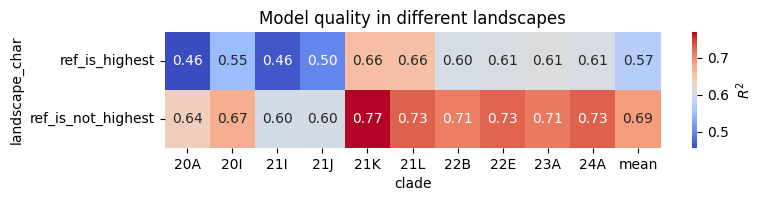

In [106]:
plt.figure(figsize=(8, 1.5))
_ = data_fitness_sites_df.pivot(columns='clade', index='landscape_char', values='r2')
_['mean'] = _.mean(axis=1)

sns.heatmap(_, annot=True, fmt='.2f', cmap='coolwarm', cbar_kws={'label': '$R^2$'})
plt.title('Model quality in different landscapes')
plt.yticks(rotation=0);